In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_pca, plot_umap, plot_tsne, plot_pca_dark, plot_umap_dark, plot_tsne_dark

# PALETTE = "pastel"            # try "muted", "pastel", "Set2", "tab10", "deep"
# sns.set_palette(PALETTE)

/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
FEATURES = Path("../../features")
METRIC = "pearson"   # switch to "spearman" to redo in that space

anchor = dict(np.load(FEATURES / f"old/data-embeddings-proof_benchmarked_260424_{METRIC}.npz", allow_pickle=True))
sweep  = dict(np.load(FEATURES / f"old/data-embeddings-cml_param_sweep_260423_{METRIC}.npz",  allow_pickle=True))

assert np.array_equal(anchor["pairs"], sweep["pairs"]), "SPI-SPI pair ordering drift between anchor and sweep"
print(f"anchor X: {anchor['X'].shape}, sweep X: {sweep['X'].shape}, pairs: {len(anchor['pairs'])}")

anchor X: (900, 42486), sweep X: (2440, 42486), pairs: 42486


In [3]:
CML = {"brownian-defect","chaotic-traveling-wave","defect-turbulence","fdstc",
       "frozen-chaos","pattern-selection","sti-i","sti-ii",
       "traveling-wave","traveling-wave-kaneko67"}

cml_mask = np.isin(anchor["y"], list(CML))
print("CML anchors:", cml_mask.sum(), "/", len(anchor["y"]))

# filter columns on the FIT population (CML anchors) before scaling
# prevents zero-variance columns from blowing up sweep projection
col_std = anchor["X"][cml_mask].std(axis=0)
keep_col = col_std >= 1e-6
print(f"dropping {(~keep_col).sum()}/{len(keep_col)} columns with CML-anchor std < 1e-6")

X_fit    = anchor["X"][cml_mask][:, keep_col]
X_sweep  = sweep["X"][:, keep_col]

scaler = StandardScaler().fit(X_fit)
pca = PCA(n_components=3, random_state=0).fit(scaler.transform(X_fit))

Z_anchor = pca.transform(scaler.transform(X_fit))
Z_sweep  = pca.transform(scaler.transform(X_sweep))

print("explained var:", pca.explained_variance_ratio_)
print("cumulative:   ", pca.explained_variance_ratio_.cumsum())

CML anchors: 500 / 900
dropping 5933/42486 columns with CML-anchor std < 1e-6
explained var: [0.20149542 0.15223747 0.07811   ]
cumulative:    [0.20149542 0.35373288 0.4318429 ]


In [4]:
X_cml = anchor["X"][cml_mask]
meta_cml = pd.DataFrame({"mts_class": anchor["y"][cml_mask]})

fig, (ax_pca, ax_umap) = plt.subplots(1, 2, figsize=(14, 7), dpi=500)

plot_pca(X_cml, meta_cml, alpha=0.6, feature_space=f"SPI-SPI {METRIC}, CML anchors",
         size_col=None, ax=ax_pca)
plot_umap(X_cml, meta_cml, n_neighbors=10, min_dist=0.75, alpha=0.6,
          feature_space=f"SPI-SPI {METRIC}, CML anchors", size_col=None, ax=ax_umap)

handles, labels = ax_pca.get_legend_handles_labels()
ax_pca.get_legend().remove()
ax_umap.get_legend().remove()
fig.legend(handles, labels, title="mts_class", loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=True)

plt.tight_layout()
plt.show()

/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 640x480 with 0 Axes>

In [5]:
print("sweep y values:", np.unique(sweep["y"]))
print("sweep variant head:", sweep["variant"][:3], "...", sweep["variant"][-3:])

alpha_mask = sweep["y"] == "cml-alpha-sweep"
eps_mask   = sweep["y"] == "cml-eps-sweep"
print(f"alpha samples: {alpha_mask.sum()}, eps samples: {eps_mask.sum()}")

def parse_slug(slug):
    return float(slug[1:].replace("p", "."))

alpha_vals = np.array([parse_slug(v) for v in sweep["variant"][alpha_mask]])
eps_vals   = np.array([parse_slug(v) for v in sweep["variant"][eps_mask]])
instances  = np.array([int(i) for i in sweep["instance"]])

alpha_grid = np.array(sorted(set(alpha_vals)))
eps_grid   = np.array(sorted(set(eps_vals)))
print(f"alpha grid: {len(alpha_grid)} values, {alpha_grid[0]:.3f} -> {alpha_grid[-1]:.3f}")
print(f"eps grid:   {len(eps_grid)} values, {eps_grid[0]:.3f} -> {eps_grid[-1]:.3f}")

# reshape into (n_grid, n_inst, n_pcs)
N_PCS = 2  # PC1+PC2 = 34.9%, going 2D
def reshape_sweep(mask, vals, grid):
    Z = Z_sweep[mask, :N_PCS]
    inst = instances[mask]
    n_inst = int(inst.max()) + 1
    out = np.full((len(grid), n_inst, N_PCS), np.nan)
    idx_of = {v: i for i, v in enumerate(grid)}
    for row, v, k in zip(Z, vals, inst):
        out[idx_of[v], k] = row
    return out, n_inst

Z_by_alpha, n_inst_a = reshape_sweep(alpha_mask, alpha_vals, alpha_grid)
Z_by_eps,   n_inst_e = reshape_sweep(eps_mask,   eps_vals,   eps_grid)
print(f"Z_by_alpha: {Z_by_alpha.shape}, Z_by_eps: {Z_by_eps.shape}")
print(f"NaN cells (alpha): {np.isnan(Z_by_alpha).any(axis=-1).sum()}, (eps): {np.isnan(Z_by_eps).any(axis=-1).sum()}")

sweep y values: ['cml-alpha-sweep' 'cml-eps-sweep']
sweep variant head: ['a1p40' 'a1p41' 'a1p42'] ... ['e0p58' 'e0p59' 'e0p60']
alpha samples: 1220, eps samples: 1220
alpha grid: 61 values, 1.400 -> 2.000
eps grid:   61 values, 0.000 -> 0.600
Z_by_alpha: (61, 20, 2), Z_by_eps: (61, 20, 2)
NaN cells (alpha): 0, (eps): 0


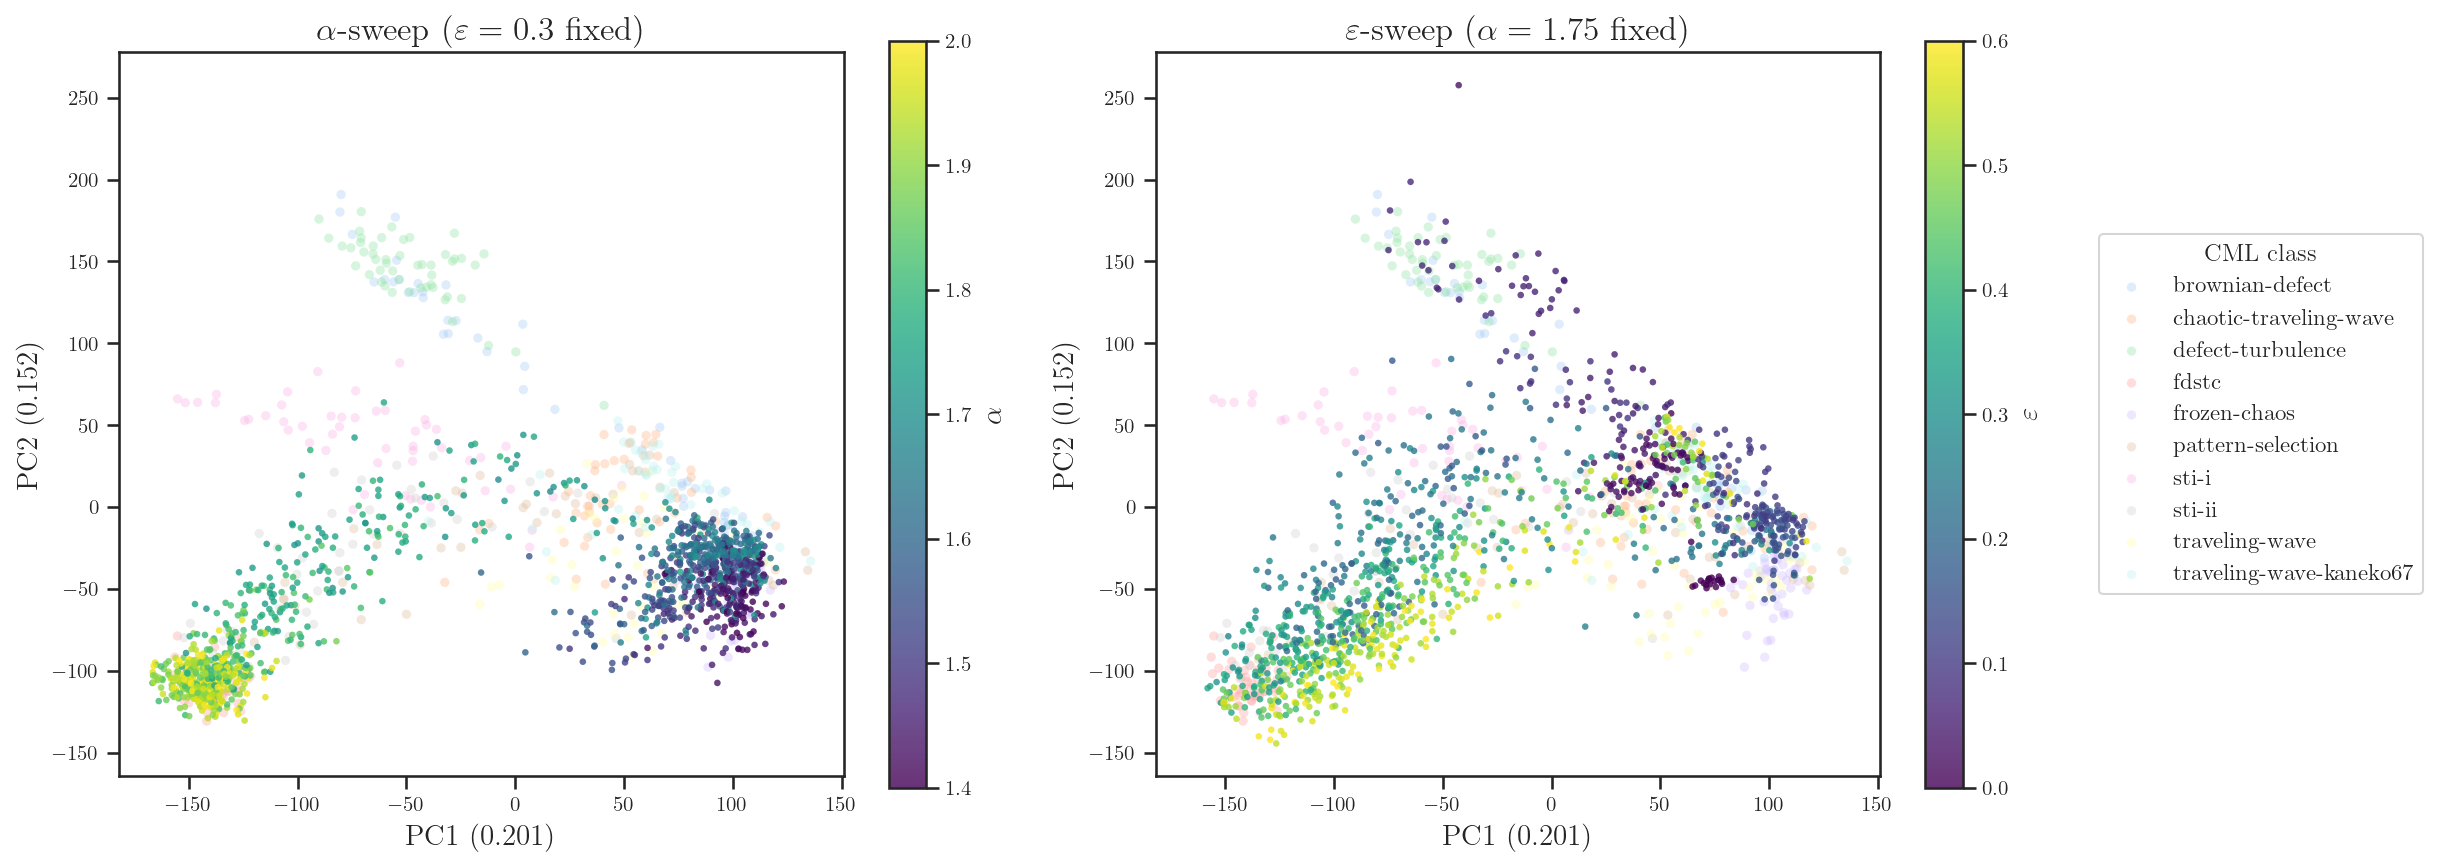

In [6]:
# shared axis limits from anchor + both sweeps
all_pts = np.vstack([Z_anchor[:, :2], Z_sweep[:, :2]])
pad = 0.05 * (all_pts.max(axis=0) - all_pts.min(axis=0))
xlim = (all_pts[:, 0].min() - pad[0], all_pts[:, 0].max() + pad[0])
ylim = (all_pts[:, 1].min() - pad[1], all_pts[:, 1].max() + pad[1])

classes = sorted(set(anchor["y"][cml_mask]))
palette = dict(zip(classes, sns.color_palette("pastel", len(classes))))
y_cml = anchor["y"][cml_mask]

fig, (ax_a, ax_e) = plt.subplots(1, 2, figsize=(14, 7), dpi=150)

for cls in classes:
    m = y_cml == cls
    for ax in (ax_a, ax_e):
        ax.scatter(Z_anchor[m, 0], Z_anchor[m, 1], c=[palette[cls]], s=20,
                   alpha=0.35, edgecolor="none", label=cls)

sc_a = ax_a.scatter(Z_sweep[alpha_mask, 0], Z_sweep[alpha_mask, 1],
                    c=alpha_vals, cmap="viridis", s=10, alpha=0.8, edgecolor="none")
sc_e = ax_e.scatter(Z_sweep[eps_mask, 0], Z_sweep[eps_mask, 1],
                    c=eps_vals, cmap="viridis", s=10, alpha=0.8, edgecolor="none")

fig.colorbar(sc_a, ax=ax_a, label=r"$\alpha$", shrink=0.75)
fig.colorbar(sc_e, ax=ax_e, label=r"$\varepsilon$", shrink=0.75)

var = pca.explained_variance_ratio_
ax_a.set_title(r"$\alpha$-sweep  ($\varepsilon = 0.3$ fixed)")
ax_e.set_title(r"$\varepsilon$-sweep  ($\alpha = 1.75$ fixed)")
for ax in (ax_a, ax_e):
    ax.set_xlabel(f"PC1 ({var[0]:.3f})")
    ax.set_ylabel(f"PC2 ({var[1]:.3f})")
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_box_aspect(1)

handles, labs = ax_a.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labs):
    seen.setdefault(l, h)
# class names with hyphens need escaping under usetex
safe_labs = [l.replace("_", r"\_") for l in seen.keys()]
fig.legend(seen.values(), safe_labs, title="CML class",
           loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=True)

plt.tight_layout()
plt.show()

In [7]:
import matplotlib.animation as animation

FPS = 5
TRAIL = 10

def animate_sweep(Z_by, grid, title_fmt, out_stem):
    fig, ax = plt.subplots(figsize=(11, 7), dpi=110)
    fig.subplots_adjust(left=0.08, right=0.62, bottom=0.08, top=0.93)

    for cls in classes:
        m = y_cml == cls
        ax.scatter(Z_anchor[m, 0], Z_anchor[m, 1], c=[palette[cls]], s=18,
                   alpha=0.45, edgecolor="none", label=cls.replace("_", r"\_"))
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel(f"PC1 ({var[0]:.3f})")
    ax.set_ylabel(f"PC2 ({var[1]:.3f})")
    ax.set_box_aspect(1)
    ax.legend(title="CML class", loc="upper left", bbox_to_anchor=(1.02, 1),
              frameon=True, fontsize=8)

    cloud = ax.scatter([], [], s=55, facecolor="none", edgecolor="black",
                       linewidth=1.0, zorder=5)
    trail = ax.scatter([], [], s=35, c="black", edgecolor="none", zorder=4)
    title = ax.set_title("")

    def update(f):
        v = grid[f]
        cloud.set_offsets(Z_by[f])
        lo = max(0, f - TRAIL)
        past = Z_by[lo:f].mean(axis=1) if f > 0 else np.empty((0, 2))
        if len(past):
            trail.set_offsets(past)
            trail.set_alpha(np.linspace(0.1, 0.8, len(past)))
        else:
            trail.set_offsets(np.empty((0, 2)))
        title.set_text(title_fmt.format(v=v))
        return cloud, trail, title

    anim = animation.FuncAnimation(fig, update, frames=len(grid),
                                   interval=1000 / FPS, blit=False)
    try:
        out = Path(f"{out_stem}.mp4")
        anim.save(out, writer="ffmpeg", fps=FPS, dpi=120)
    except Exception as e:
        print(f"ffmpeg unavailable ({type(e).__name__}); saving gif")
        out = Path(f"{out_stem}.gif")
        anim.save(out, writer="pillow", fps=FPS, dpi=100)
    plt.close(fig)
    print(f"saved {out}")
    return out

animate_sweep(Z_by_alpha, alpha_grid,
              r"$\alpha = {v:.2f}$  ($\varepsilon = 0.3$ fixed)",
              f"alpha_sweep_{METRIC}")
animate_sweep(Z_by_eps, eps_grid,
              r"$\varepsilon = {v:.2f}$  ($\alpha = 1.75$ fixed)",
              f"eps_sweep_{METRIC}")

saved alpha_sweep_pearson.mp4
saved eps_sweep_pearson.mp4


PosixPath('eps_sweep_pearson.mp4')

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import gaussian_kde

knn2 = KNeighborsClassifier(n_neighbors=15).fit(Z_anchor[:, :2], y_cml)
gx, gy = np.mgrid[xlim[0]:xlim[1]:80j, ylim[0]:ylim[1]:80j]
kde_grid_pts = np.vstack([gx.ravel(), gy.ravel()])

def animate_kde(Z_by, grid, title_fmt, out_stem):
    fig, ax = plt.subplots(figsize=(11, 7), dpi=110)
    fig.subplots_adjust(left=0.08, right=0.62, bottom=0.08, top=0.93)
    for cls in classes:
        m = y_cml == cls
        ax.scatter(Z_anchor[m, 0], Z_anchor[m, 1], c=[palette[cls]], s=18,
                   alpha=0.40, edgecolor="none", label=cls.replace("_", r"\_"))
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel(f"PC1 ({var[0]:.3f})"); ax.set_ylabel(f"PC2 ({var[1]:.3f})")
    ax.set_box_aspect(1)
    ax.legend(title="CML class", loc="upper left", bbox_to_anchor=(1.02, 1),
              frameon=True, fontsize=8)

    trail = ax.scatter([], [], s=45, edgecolor="black", linewidth=0.4, zorder=4)
    title = ax.set_title("")
    current_cs = [None]

    def update(f):
        v = grid[f]; pts = Z_by[f]
        if current_cs[0] is not None:
            current_cs[0].remove(); current_cs[0] = None
        kde = gaussian_kde(pts.T, bw_method=0.35)
        dens = kde(kde_grid_pts).reshape(gx.shape)
        level = np.percentile(kde(pts.T), 20)
        cls_pred = knn2.predict(pts.mean(axis=0, keepdims=True))[0]
        current_cs[0] = ax.contourf(gx, gy, dens,
                                    levels=[level, dens.max() + 1e-12],
                                    colors=[palette[cls_pred]], alpha=0.55, zorder=3)
        lo = max(0, f - TRAIL)
        past = Z_by[lo:f].mean(axis=1) if f > 0 else np.empty((0, 2))
        if len(past):
            past_cls = knn2.predict(past)
            rgba = np.ones((len(past), 4))
            rgba[:, :3] = np.array([palette[c] for c in past_cls])
            rgba[:, 3] = np.linspace(0.15, 0.9, len(past))
            trail.set_offsets(past); trail.set_facecolor(rgba)
        else:
            trail.set_offsets(np.empty((0, 2)))
            trail.set_facecolor(np.empty((0, 4)))
        title.set_text(title_fmt.format(v=v))
        return [trail, title]

    anim = animation.FuncAnimation(fig, update, frames=len(grid),
                                   interval=1000 / FPS, blit=False)
    try:
        out = Path(f"{out_stem}.mp4"); anim.save(out, writer="ffmpeg", fps=FPS, dpi=120)
    except Exception as e:
        print(f"ffmpeg unavailable ({type(e).__name__}); saving gif")
        out = Path(f"{out_stem}.gif"); anim.save(out, writer="pillow", fps=FPS, dpi=100)
    plt.close(fig); print(f"saved {out}"); return out

animate_kde(Z_by_alpha, alpha_grid,
            r"$\alpha = {v:.2f}$  ($\varepsilon = 0.3$ fixed)",
            f"alpha_sweep_kde_{METRIC}")
animate_kde(Z_by_eps, eps_grid,
            r"$\varepsilon = {v:.2f}$  ($\alpha = 1.75$ fixed)",
            f"eps_sweep_kde_{METRIC}")

saved alpha_sweep_kde_pearson.mp4
saved eps_sweep_kde_pearson.mp4


PosixPath('eps_sweep_kde_pearson.mp4')

In [9]:
import plotly.graph_objects as go

# 3D reshape + axis limits + 3D kNN (reuse 2D vars from earlier cells)
def reshape_sweep_nd(mask, vals, grid, ndim):
    Z = Z_sweep[mask, :ndim]; inst = instances[mask]
    out = np.full((len(grid), int(inst.max()) + 1, ndim), np.nan)
    idx_of = {v: i for i, v in enumerate(grid)}
    for row, v, k in zip(Z, vals, inst): out[idx_of[v], k] = row
    return out

Z_by_alpha_3d = reshape_sweep_nd(alpha_mask, alpha_vals, alpha_grid, 3)
Z_by_eps_3d   = reshape_sweep_nd(eps_mask,   eps_vals,   eps_grid, 3)

all_pts_3d = np.vstack([Z_anchor[:, :3], Z_sweep[:, :3]])
pad3 = 0.05 * (all_pts_3d.max(axis=0) - all_pts_3d.min(axis=0))
xlim3 = (all_pts_3d[:, 0].min() - pad3[0], all_pts_3d[:, 0].max() + pad3[0])
ylim3 = (all_pts_3d[:, 1].min() - pad3[1], all_pts_3d[:, 1].max() + pad3[1])
zlim3 = (all_pts_3d[:, 2].min() - pad3[2], all_pts_3d[:, 2].max() + pad3[2])

knn3 = KNeighborsClassifier(n_neighbors=15).fit(Z_anchor[:, :3], y_cml)

def rgb_str(rgb): return f"rgb({int(rgb[0]*255)},{int(rgb[1]*255)},{int(rgb[2]*255)})"
def rgba_str(rgb, a): return f"rgba({int(rgb[0]*255)},{int(rgb[1]*255)},{int(rgb[2]*255)},{a:.3f})"

def make_plotly_sweep(Z_by, grid, param_label, title, three_d=False):
    ScatterCls = go.Scatter3d if three_d else go.Scatter
    knn_ = knn3 if three_d else knn2
    ndim = 3 if three_d else 2

    anchor_traces = []
    for cls in classes:
        m = y_cml == cls
        kw = dict(x=Z_anchor[m, 0], y=Z_anchor[m, 1], mode="markers",
                  name=cls, legendgroup="anchor",
                  marker=dict(color=rgb_str(palette[cls]),
                              size=(3 if three_d else 6), opacity=0.5))
        if three_d: kw["z"] = Z_anchor[m, 2]
        anchor_traces.append(ScatterCls(**kw))
    n_anchor = len(anchor_traces)

    frames = []
    for f, v in enumerate(grid):
        pts = Z_by[f]
        lo = max(0, f - TRAIL)
        past = Z_by[lo:f].mean(axis=1) if f > 0 else np.empty((0, ndim))
        if len(past):
            past_cls = knn_.predict(past)
            alphas = np.linspace(0.15, 0.9, len(past))
            past_colors = [rgba_str(palette[c], a) for c, a in zip(past_cls, alphas)]
        else:
            past_colors = ["black"]

        if three_d:
            cloud_m = dict(color="black", size=4, opacity=0.9)
            trail_m = dict(color=past_colors, size=5, opacity=1.0)
        else:
            cloud_m = dict(color="rgba(0,0,0,0)", size=9, line=dict(color="black", width=1.3))
            trail_m = dict(color=past_colors, size=8, line=dict(color="black", width=0.3))

        cloud_kw = dict(x=pts[:, 0], y=pts[:, 1], mode="markers",
                        marker=cloud_m, showlegend=False, name="cloud")
        trail_kw = dict(x=past[:, 0] if len(past) else [],
                        y=past[:, 1] if len(past) else [],
                        mode="markers", marker=trail_m,
                        showlegend=False, name="trail")
        if three_d:
            cloud_kw["z"] = pts[:, 2]
            trail_kw["z"] = past[:, 2] if len(past) else []
        frames.append(go.Frame(
            data=[ScatterCls(**cloud_kw), ScatterCls(**trail_kw)],
            traces=[n_anchor, n_anchor + 1], name=f"{v:.2f}"))

    fig = go.Figure(data=anchor_traces + list(frames[0].data), frames=frames)

    steps = [dict(method="animate",
                  args=[[f.name], dict(frame=dict(duration=0, redraw=True), mode="immediate")],
                  label=f.name) for f in frames]
    sliders = [dict(steps=steps,
                    currentvalue=dict(prefix=f"{param_label} = ", font=dict(size=14)),
                    x=0.08, xanchor="left", y=0, yanchor="top",
                    len=0.85, pad=dict(b=10, t=40))]
    play_btn = dict(label="Play", method="animate",
                    args=[None, dict(frame=dict(duration=200, redraw=True),
                                      fromcurrent=True, transition=dict(duration=0))])
    pause_btn = dict(label="Pause", method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])

    layout_kw = dict(title=title, sliders=sliders, width=900, height=700,
                     legend=dict(title="CML class"),
                     updatemenus=[dict(type="buttons", showactive=False,
                                       x=0, y=0, xanchor="right", yanchor="top",
                                       pad=dict(t=40, r=10),
                                       buttons=[play_btn, pause_btn])])
    if three_d:
        layout_kw["scene"] = dict(
            xaxis=dict(range=list(xlim3), title=f"PC1 ({var[0]:.3f})"),
            yaxis=dict(range=list(ylim3), title=f"PC2 ({var[1]:.3f})"),
            zaxis=dict(range=list(zlim3), title=f"PC3 ({var[2]:.3f})"),
            aspectmode="cube")
    else:
        layout_kw["xaxis"] = dict(range=list(xlim), title=f"PC1 ({var[0]:.3f})")
        layout_kw["yaxis"] = dict(range=list(ylim), title=f"PC2 ({var[1]:.3f})",
                                   scaleanchor="x", scaleratio=1)
    fig.update_layout(**layout_kw)
    return fig

# 4 separate figures
make_plotly_sweep(Z_by_alpha,    alpha_grid, "alpha", "alpha-sweep (eps=0.3) - 2D").show()
make_plotly_sweep(Z_by_eps,      eps_grid,   "eps",   "eps-sweep (alpha=1.75) - 2D").show()
make_plotly_sweep(Z_by_alpha_3d, alpha_grid, "alpha", "alpha-sweep (eps=0.3) - 3D", three_d=True).show()
make_plotly_sweep(Z_by_eps_3d,   eps_grid,   "eps",   "eps-sweep (alpha=1.75) - 3D", three_d=True).show()

In [10]:
def make_plotly_combo(Z_a, Z_e, g_a, g_e, title, three_d=False):
    ScatterCls = go.Scatter3d if three_d else go.Scatter
    knn_ = knn3 if three_d else knn2
    ndim = 3 if three_d else 2

    anchor_traces = []
    for cls in classes:
        m = y_cml == cls
        kw = dict(x=Z_anchor[m, 0], y=Z_anchor[m, 1], mode="markers",
                  name=cls, legendgroup="anchor",
                  marker=dict(color=rgb_str(palette[cls]),
                              size=(3 if three_d else 6), opacity=0.5))
        if three_d: kw["z"] = Z_anchor[m, 2]
        anchor_traces.append(ScatterCls(**kw))
    n_anchor = len(anchor_traces)

    def build_pair(Z_by, f, visible):
        pts = Z_by[f]
        lo = max(0, f - TRAIL)
        past = Z_by[lo:f].mean(axis=1) if f > 0 else np.empty((0, ndim))
        if len(past):
            past_cls = knn_.predict(past)
            alphas = np.linspace(0.15, 0.9, len(past))
            past_colors = [rgba_str(palette[c], a) for c, a in zip(past_cls, alphas)]
        else:
            past_colors = ["black"]
        if three_d:
            cloud_m = dict(color="black", size=4, opacity=0.9)
            trail_m = dict(color=past_colors, size=5, opacity=1.0)
        else:
            cloud_m = dict(color="rgba(0,0,0,0)", size=9, line=dict(color="black", width=1.3))
            trail_m = dict(color=past_colors, size=8, line=dict(color="black", width=0.3))
        cloud_kw = dict(x=pts[:, 0], y=pts[:, 1], mode="markers",
                        marker=cloud_m, showlegend=False, name="cloud")
        trail_kw = dict(x=past[:, 0] if len(past) else [],
                        y=past[:, 1] if len(past) else [],
                        mode="markers", marker=trail_m,
                        showlegend=False, name="trail")
        if three_d:
            cloud_kw["z"] = pts[:, 2]
            trail_kw["z"] = past[:, 2] if len(past) else []
        if visible is not None:
            cloud_kw["visible"] = visible; trail_kw["visible"] = visible
        return ScatterCls(**cloud_kw), ScatterCls(**trail_kw)

    a_cloud0, a_trail0 = build_pair(Z_a, 0, True)
    e_cloud0, e_trail0 = build_pair(Z_e, 0, False)

    frames = []
    n = min(len(g_a), len(g_e))
    for f in range(n):
        a_cloud, a_trail = build_pair(Z_a, f, None)
        e_cloud, e_trail = build_pair(Z_e, f, None)
        frames.append(go.Frame(
            data=[a_cloud, a_trail, e_cloud, e_trail],
            traces=[n_anchor, n_anchor + 1, n_anchor + 2, n_anchor + 3],
            name=f"{f}"))

    fig = go.Figure(data=anchor_traces + [a_cloud0, a_trail0, e_cloud0, e_trail0],
                    frames=frames)

    alpha_vis = [True] * n_anchor + [True, True, False, False]
    eps_vis   = [True] * n_anchor + [False, False, True, True]

    steps = [dict(method="animate",
                  args=[[fr.name], dict(frame=dict(duration=0, redraw=True), mode="immediate")],
                  label=f"{g_a[int(fr.name)]:.2f} / {g_e[int(fr.name)]:.2f}")
             for fr in frames]
    sliders = [dict(steps=steps,
                    currentvalue=dict(prefix="alpha / eps = ", font=dict(size=14)),
                    x=0.08, xanchor="left", y=0, yanchor="top",
                    len=0.85, pad=dict(b=10, t=40))]

    dropdown = dict(type="dropdown", showactive=True,
                    x=0, y=1.12, xanchor="left", yanchor="top",
                    buttons=[
                        dict(label="alpha-sweep", method="update",
                             args=[{"visible": alpha_vis}, {}]),
                        dict(label="eps-sweep", method="update",
                             args=[{"visible": eps_vis}, {}]),
                    ])
    play_btn = dict(label="Play", method="animate",
                    args=[None, dict(frame=dict(duration=200, redraw=True),
                                      fromcurrent=True, transition=dict(duration=0))])
    pause_btn = dict(label="Pause", method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])
    play_menu = dict(type="buttons", showactive=False,
                     x=0.3, y=1.12, xanchor="left", yanchor="top",
                     buttons=[play_btn, pause_btn])

    layout_kw = dict(title=title, sliders=sliders,
                     updatemenus=[dropdown, play_menu],
                     width=900, height=750, legend=dict(title="CML class"))
    if three_d:
        layout_kw["scene"] = dict(
            xaxis=dict(range=list(xlim3), title=f"PC1 ({var[0]:.3f})"),
            yaxis=dict(range=list(ylim3), title=f"PC2 ({var[1]:.3f})"),
            zaxis=dict(range=list(zlim3), title=f"PC3 ({var[2]:.3f})"),
            aspectmode="cube")
    else:
        layout_kw["xaxis"] = dict(range=list(xlim), title=f"PC1 ({var[0]:.3f})")
        layout_kw["yaxis"] = dict(range=list(ylim), title=f"PC2 ({var[1]:.3f})",
                                   scaleanchor="x", scaleratio=1)
    fig.update_layout(**layout_kw)
    return fig

make_plotly_combo(Z_by_alpha,    Z_by_eps,    alpha_grid, eps_grid,
                  "2D - toggle sweep via dropdown").show()
make_plotly_combo(Z_by_alpha_3d, Z_by_eps_3d, alpha_grid, eps_grid,
                  "3D - toggle sweep via dropdown", three_d=True).show()